# 05 — Expérience : le marché est-il battable ? (efficience des cotes)
**Objectif scientifique, pas de pari.** On simule des stratégies sur le test 2021-2026 et on mesure le rendement moyen par mise unitaire avec un intervalle de confiance à 95 %.
Une stratégie n'est « gagnante » que si l'intervalle entier est au-dessus de 0.

In [1]:
# ── Installation : fonctionne dans Colab (clone le dépôt) comme en local (depuis le dossier notebooks/) ──
import os, sys
DEPOT = "https://github.com/abdelkbir1243/football-prediction-stat.git"   # ← adapter si le dépôt a un autre nom
if os.path.exists("../footpred"):
    os.chdir("..")
elif not os.path.exists("footpred"):
    os.system(f"git clone -q {DEPOT}"); os.chdir("football-prediction-stat")
    os.system("pip -q install -r requirements.txt")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from footpred import preparer, labo, journal, config
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

In [2]:
pred = preparer()
res = labo.strategies(pred.d)
labo.enregistrer(res, 'strategies_2021_2026')
res['strategies'].style.format({'gagnés': '{:.1%}', 'rendement': '{:+.1%}', 'IC bas': '{:+.1%}', 'IC haut': '{:+.1%}'})

,paris,gagnés,rendement,IC bas,IC haut
stratégie,,,,,
"value v4 vs cote moyenne, seuil 0%",9209,31.7%,-5.8%,-8.9%,-2.3%
"value v4 vs cote moyenne, seuil 5%",5512,29.1%,-8.4%,-12.7%,-4.1%
"value v4 vs cote moyenne, seuil 10%",3099,26.6%,-10.7%,-16.7%,-4.5%
"value v4 vs cote moyenne, seuil 20%",1109,19.8%,-21.1%,-31.6%,-11.0%
"value v4 vs meilleure cote, seuil 0%",13011,31.3%,-2.0%,-5.0%,+1.1%
"value v4 vs meilleure cote, seuil 5%",8745,29.2%,-2.4%,-6.0%,+1.4%
toujours le favori,8821,53.7%,-2.2%,-4.2%,-0.3%
toujours le nul,8821,25.4%,-2.5%,-6.0%,+1.1%
toujours l'outsider,8821,20.7%,-10.4%,-14.4%,-6.2%


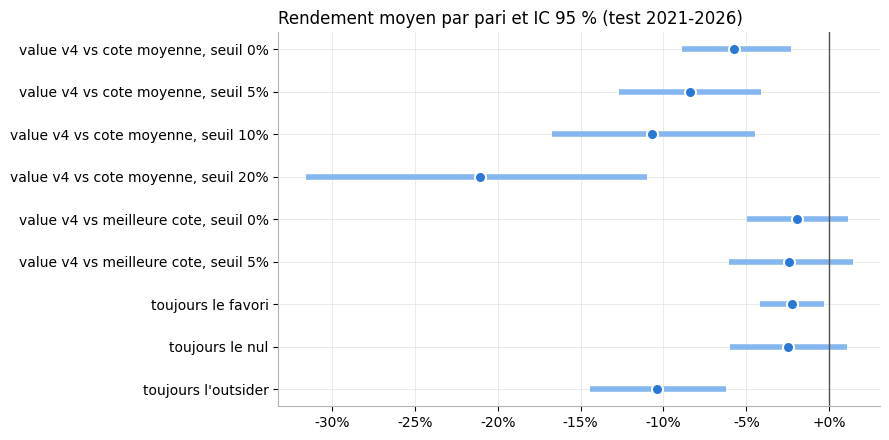

In [3]:
t = res["strategies"]; fig, ax = plt.subplots(figsize=(9, 4.5)); yy = np.arange(len(t))[::-1]
ax.hlines(yy, t["IC bas"], t["IC haut"], color="#86b6ef", lw=4); ax.plot(t.rendement, yy, "o", color="#2a78d6", ms=8, mec="white", mew=1.5)
ax.axvline(0, color="#52514e", lw=1); ax.set_yticks(yy, t.index); ax.xaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_title("Rendement moyen par pari et IC 95 % (test 2021-2026)", loc="left"); plt.tight_layout(); plt.show()

## Lecture
- Parier dès que le modèle « voit de la value » **perd**, et d'autant plus que le seuil est exigeant : ces écarts sont surtout les erreurs du modèle.
- Le seul biais net est le **biais favori-outsider** : jouer les outsiders perd le plus.
- Conclusion : le marché intègre déjà l'information du modèle (et davantage : compositions, blessures). Résultat cohérent avec Štrumbelj (2014), Hubáček et al. (2019), Kaunitz et al. (2017).

Voir aussi `docs/resultats.md` §5-6 : ajouter jusqu'à 112 variables n'améliore plus le modèle (surapprentissage).